# Conditional Variational AutoEncoder on MNIST

Conditional VAE, CVAE, 是 VAE 的条件版本。普通 VAE 学习：

$$q(z \mid x), \quad p(x \mid z)$$

Conditional VAE 额外给模型一个条件 $y$。在 MNIST 中，$y$ 就是 digit label。模型学习：

$$q(z \mid x, y), \quad p(x \mid z, y)$$

直观理解：

- label $y$ 控制“要生成哪个数字”。
- latent vector $z$ 控制同一个数字内部的变化，例如粗细、倾斜、形状细节。

本 notebook 使用 MNIST 训练一个小型 Conditional VAE，重点观察：

- Conditional VAE 如何把 label condition 输入 encoder 和 decoder。
- VAE loss 包含 reconstruction loss 和 KL loss。
- 如何用 PCA 可视化 64 维 latent mean vectors。
- 如何在原始 64 维 latent space 中插值并 decode。
- 如何指定 digit label 做 conditional generation。

为了更快看到结果，本 notebook 优先使用 CUDA，并设置 `BATCH_SIZE = 1024`。

**AI 使用指引。** 如果 VAE 和 Conditional VAE 的区别不清楚，可以问 AI：`VAE 学的是 p(x|z)，Conditional VAE 学的是 p(x|z,y)，这个 y 在生成 MNIST 时起什么作用？z 和 y 分别控制什么？` 重点是理解 conditional generation 中 label 是显式输入，而不是模型自己猜出来的变量。

## 1. 准备环境

In [25]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.decomposition import PCA
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

sns.set_theme(style="white", context="notebook", font_scale=1.05)
plt.rcParams["figure.dpi"] = 150

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device = {device}")
if device.type == "cpu":
    print("CUDA is not available. The notebook will still run, but training will be slower.")

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "generative_models" else Path.cwd()
DATA_DIR = REPO_ROOT / "data"
OUTPUT_DIR = REPO_ROOT / "outputs" / "figures"

SAVE_FIGURES = False

device = cuda


## 2. 准备 MNIST 数据

Conditional VAE 训练时会使用 digit label 作为 condition。输入是图片 `images` 和标签 `labels`，重建目标仍然是同一批 `images`。

这里使用完整 MNIST training set 和 test set。训练使用官方 60,000 张 training images；latent PCA、插值和 conditional generation 展示使用官方 10,000 张 test images。

In [26]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root=DATA_DIR, train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root=DATA_DIR, train=False, download=True, transform=transform)

BATCH_SIZE = 1024
PIN_MEMORY = device.type == "cuda"

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=PIN_MEMORY)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=PIN_MEMORY)

images, labels = next(iter(train_loader))
print(f"training images used = {len(train_dataset)}")
print(f"test images used = {len(test_dataset)}")
print(f"images.shape = {tuple(images.shape)}")
print(f"labels.shape = {tuple(labels.shape)}")

training images used = 60000
test images used = 10000
images.shape = (1024, 1, 28, 28)
labels.shape = (1024,)


## 3. 定义 Conditional VAE

Conditional VAE 的 encoder 接收图片和 label：

$$q(z \mid x, y)$$

Decoder 接收 latent vector 和 label：

$$p(x \mid z, y)$$

代码里把 label 转成 one-hot vector，形状是 `(B, 10)`。然后：

- encoder 输入：`flatten(image)` 和 `one_hot(label)` 拼接，形状 `(B, 784 + 10)`。
- decoder 输入：`latent` 和 `one_hot(label)` 拼接，形状 `(B, 64 + 10)`。

Encoder 输出两个向量：

- `mu`: latent normal distribution 的均值，形状 `(B, 64)`。
- `logvar`: latent normal distribution 的 log variance，形状 `(B, 64)`。

采样仍然使用 reparameterization trick：

$$z = \mu + \sigma \odot \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)$$

**AI 使用指引。** 如果 conditional input 的位置不清楚，可以问 AI：`Conditional VAE 中为什么 encoder 和 decoder 都要接收 label y？如果只在 decoder 输入 y，会发生什么？` 重点是理解训练时 encoder 学的是 $q(z|x,y)$，生成时 decoder 用 $p(x|z,y)$ 指定类别。

In [27]:
LATENT_DIM = 64
NUM_CLASSES = 10


def labels_to_one_hot(labels, num_classes=10):
    return F.one_hot(labels, num_classes=num_classes).float()


class ConditionalMNISTVAE(nn.Module):
    def __init__(self, latent_dim=64, num_classes=10):
        super().__init__()
        self.latent_dim = latent_dim
        self.num_classes = num_classes

        self.encoder_backbone = nn.Sequential(
            nn.Linear(28 * 28 + num_classes, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
        )
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim + num_classes, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 28 * 28),
            nn.Sigmoid(),
        )

    def encode(self, images, labels):
        X = images.view(images.shape[0], -1)
        y_one_hot = labels_to_one_hot(labels, self.num_classes).to(images.device)
        encoder_input = torch.cat([X, y_one_hot], dim=1)
        hidden = self.encoder_backbone(encoder_input)
        mu = self.fc_mu(hidden)
        logvar = self.fc_logvar(hidden)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        epsilon = torch.randn_like(std)
        return mu + std * epsilon

    def decode(self, latent, labels):
        y_one_hot = labels_to_one_hot(labels, self.num_classes).to(latent.device)
        decoder_input = torch.cat([latent, y_one_hot], dim=1)
        reconstruction_flat = self.decoder(decoder_input)
        return reconstruction_flat

    def decode_with_condition_vector(self, latent, condition_vector):
        decoder_input = torch.cat([latent, condition_vector.to(latent.device)], dim=1)
        reconstruction_flat = self.decoder(decoder_input)
        return reconstruction_flat

    def forward(self, images, labels):
        mu, logvar = self.encode(images, labels)
        latent = self.reparameterize(mu, logvar)
        reconstruction_flat = self.decode(latent, labels)
        return reconstruction_flat, mu, logvar, latent


model = ConditionalMNISTVAE(latent_dim=LATENT_DIM, num_classes=NUM_CLASSES).to(device)
print(model)

ConditionalMNISTVAE(
  (encoder_backbone): Sequential(
    (0): Linear(in_features=794, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
  )
  (fc_mu): Linear(in_features=256, out_features=64, bias=True)
  (fc_logvar): Linear(in_features=256, out_features=64, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=74, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=784, bias=True)
    (5): Sigmoid()
  )
)


检查一个 batch 经过 Conditional VAE 后的形状。

In [28]:
images = images.to(device, non_blocking=True)
labels = labels.to(device, non_blocking=True)
reconstruction_flat, mu, logvar, latent = model(images, labels)

print(f"input images.shape = {tuple(images.shape)}")
print(f"labels.shape = {tuple(labels.shape)}")
print(f"one_hot labels.shape = {tuple(labels_to_one_hot(labels, NUM_CLASSES).shape)}")
print(f"mu.shape = {tuple(mu.shape)}")
print(f"logvar.shape = {tuple(logvar.shape)}")
print(f"latent.shape = {tuple(latent.shape)}")
print(f"reconstruction_flat.shape = {tuple(reconstruction_flat.shape)}")

input images.shape = (1024, 1, 28, 28)
labels.shape = (1024,)
one_hot labels.shape = (1024, 10)
mu.shape = (1024, 64)
logvar.shape = (1024, 64)
latent.shape = (1024, 64)
reconstruction_flat.shape = (1024, 784)


## 4. Conditional VAE loss

Conditional VAE 的 loss 和普通 VAE 形式相同。这里不做推导，只给出训练时需要的形式：

$$\mathcal{L} = \mathcal{L}_{\text{reconstruction}} + \beta\mathcal{L}_{\text{KL}}$$

第一项让重建图 $\hat{x}$ 接近原图 $x$。第二项让 encoder 输出的 $q(z \mid x, y)$ 接近标准正态分布 $\mathcal{N}(0, I)$。

本 notebook 使用 binary cross entropy 作为 reconstruction loss，使用标准 VAE 的 KL 项：

$$\mathcal{L}_{\text{KL}} = -\frac{1}{2}\sum_j (1 + \log\sigma_j^2 - \mu_j^2 - \sigma_j^2)$$

代码中用 `logvar` 表示 $\log\sigma^2$。Label condition 不额外增加一个 loss；它只是模型输入的一部分。

**AI 使用指引。** 如果 Conditional VAE loss 的两项容易混，可以问 AI：`Conditional VAE 中 reconstruction loss 和 KL loss 分别约束什么？label y 是如何进入模型的，为什么 loss 公式本身看起来和 VAE 一样？` 重点是理解 condition 改变的是建模对象 $q(z|x,y)$ 和 $p(x|z,y)$，不是额外多一个分类 loss。

In [29]:
def vae_loss(reconstruction_flat, images, mu, logvar, beta=1.0):
    targets = images.view(images.shape[0], -1)

    # Sum over pixels/latent dimensions, then divide by batch size.
    reconstruction_loss = F.binary_cross_entropy(
        reconstruction_flat,
        targets,
        reduction="sum",
    ) / images.shape[0]

    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / images.shape[0]
    loss = reconstruction_loss + beta * kl_loss
    return loss, reconstruction_loss, kl_loss


loss, reconstruction_loss, kl_loss = vae_loss(reconstruction_flat, images, mu, logvar)
print(f"total loss = {loss.item():.3f}")
print(f"reconstruction loss = {reconstruction_loss.item():.3f}")
print(f"KL loss = {kl_loss.item():.3f}")

total loss = 544.105
reconstruction loss = 543.978
KL loss = 0.127


## 5. 训练 VAE

In [30]:
optimizer = torch.optim.Adam(model.parameters(), lr=5e-3)
EPOCHS = 30
BETA = 1.0

history = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0
    total_reconstruction = 0.0
    total_kl = 0.0
    total_examples = 0

    for images, labels in train_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        reconstruction_flat, mu, logvar, latent = model(images, labels)
        loss, reconstruction_loss, kl_loss = vae_loss(reconstruction_flat, images, mu, logvar, beta=BETA)
        loss.backward()
        optimizer.step()

        batch_size = images.shape[0]
        total_loss += loss.item() * batch_size
        total_reconstruction += reconstruction_loss.item() * batch_size
        total_kl += kl_loss.item() * batch_size
        total_examples += batch_size

    epoch_loss = total_loss / total_examples
    epoch_reconstruction = total_reconstruction / total_examples
    epoch_kl = total_kl / total_examples
    history.append({
        "epoch": epoch + 1,
        "loss": epoch_loss,
        "reconstruction_loss": epoch_reconstruction,
        "kl_loss": epoch_kl,
    })
    print(
        f"epoch {epoch + 1}: loss = {epoch_loss:.3f}, "
        f"reconstruction = {epoch_reconstruction:.3f}, KL = {epoch_kl:.3f}"
    )

epoch 1: loss = 214.931, reconstruction = 212.850, KL = 2.082
epoch 2: loss = 171.911, reconstruction = 168.215, KL = 3.696
epoch 3: loss = 148.823, reconstruction = 141.871, KL = 6.952
epoch 4: loss = 135.335, reconstruction = 126.645, KL = 8.690
epoch 5: loss = 127.174, reconstruction = 117.649, KL = 9.525
epoch 6: loss = 122.501, reconstruction = 112.332, KL = 10.169
epoch 7: loss = 119.279, reconstruction = 108.275, KL = 11.004
epoch 8: loss = 116.374, reconstruction = 104.828, KL = 11.546
epoch 9: loss = 114.015, reconstruction = 102.063, KL = 11.952
epoch 10: loss = 112.519, reconstruction = 100.354, KL = 12.166
epoch 11: loss = 111.426, reconstruction = 99.050, KL = 12.376
epoch 12: loss = 110.383, reconstruction = 97.835, KL = 12.548
epoch 13: loss = 109.833, reconstruction = 97.150, KL = 12.683
epoch 14: loss = 109.009, reconstruction = 96.208, KL = 12.801
epoch 15: loss = 108.452, reconstruction = 95.528, KL = 12.924
epoch 16: loss = 107.891, reconstruction = 94.817, KL = 13.

## 6. 查看重建结果

重建图像来自 encoder 输出的 distribution 采样得到的 latent vector，并且 decoder 同时接收对应的 digit label condition。因为 VAE 需要同时满足重建和 KL 约束，重建图通常会比普通 AutoEncoder 更模糊一些。

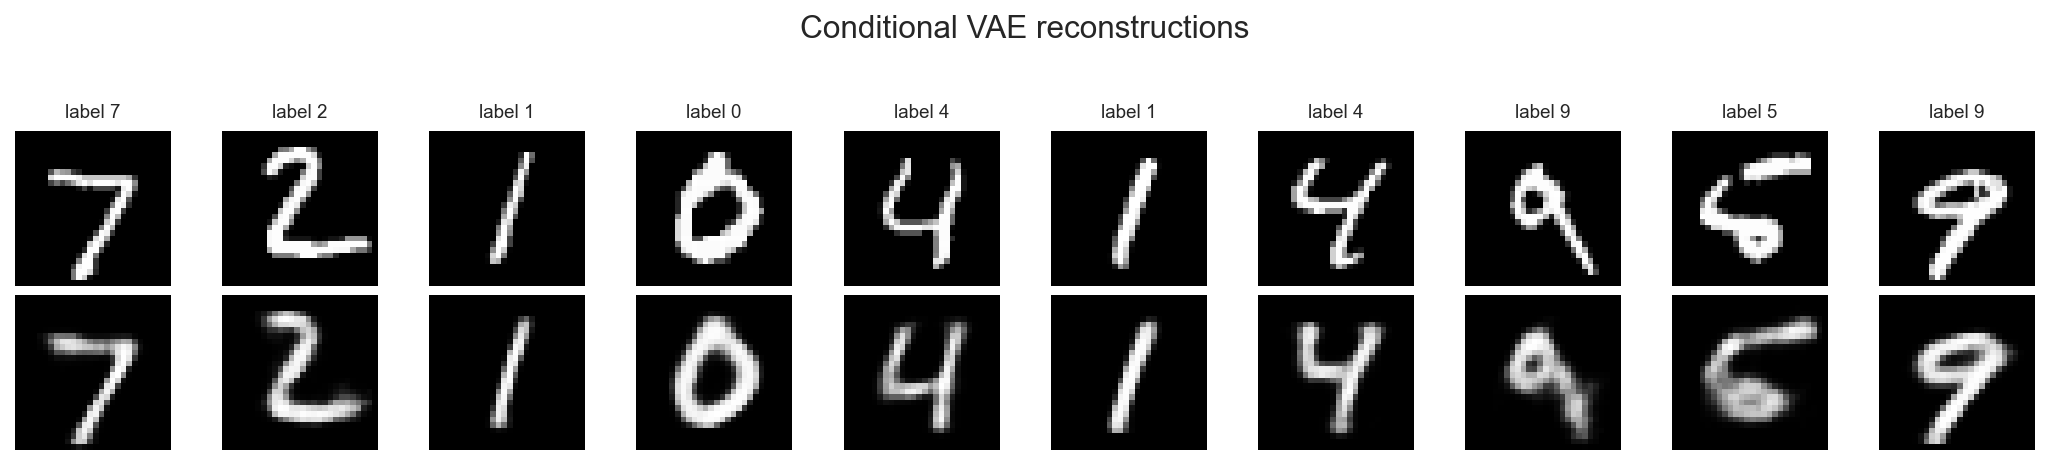

In [31]:
def show_reconstructions(model, loader, num_images=10):
    model.eval()
    images, labels = next(iter(loader))
    images = images[:num_images].to(device, non_blocking=True)
    labels = labels[:num_images].to(device, non_blocking=True)

    with torch.no_grad():
        reconstruction_flat, mu, logvar, latent = model(images, labels)
        reconstructions = reconstruction_flat.view(-1, 1, 28, 28).cpu()

    originals = images.cpu()
    labels_cpu = labels.cpu()
    fig, axes = plt.subplots(2, num_images, figsize=(1.4 * num_images, 3.0))

    for col in range(num_images):
        axes[0, col].imshow(originals[col].squeeze(0), cmap="gray")
        axes[0, col].set_title(f"label {labels_cpu[col].item()}", fontsize=9)
        axes[0, col].axis("off")

        axes[1, col].imshow(reconstructions[col].squeeze(0), cmap="gray")
        axes[1, col].axis("off")

    axes[0, 0].set_ylabel("Original", fontsize=11)
    axes[1, 0].set_ylabel("Recon", fontsize=11)
    fig.suptitle("Conditional VAE reconstructions", y=1.03)
    plt.tight_layout()
    return fig


fig = show_reconstructions(model, test_loader, num_images=10)

if SAVE_FIGURES:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(OUTPUT_DIR / "conditional_vae_mnist_reconstructions.png", dpi=300, bbox_inches="tight")
    fig.savefig(OUTPUT_DIR / "conditional_vae_mnist_reconstructions.svg", bbox_inches="tight")

## 7. 收集 latent mean vectors

Conditional VAE encoder 输出的是 $q(z \mid x, y)$。为了稳定地可视化 latent representation，我们收集每张 test image 在真实 label condition 下对应的 `mu`，也就是 posterior mean vector。

In [32]:
def collect_latent_means(model, loader):
    model.eval()
    mu_batches = []
    label_batches = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels_device = labels.to(device, non_blocking=True)
            mu, logvar = model.encode(images, labels_device)
            mu_batches.append(mu.cpu())
            label_batches.append(labels)

    latent_mu = torch.cat(mu_batches, dim=0).numpy()
    labels = torch.cat(label_batches, dim=0).numpy()
    return latent_mu, labels


latent_mu, latent_labels = collect_latent_means(model, test_loader)
print(f"latent_mu.shape = {latent_mu.shape}")
print(f"latent_labels.shape = {latent_labels.shape}")

latent_mu.shape = (10000, 64)
latent_labels.shape = (10000,)


## 8. PCA 可视化 Conditional VAE latent space

`LATENT_DIM = 64` 时，`mu` 是 64 维向量。PCA 会把这些 64 维 vectors 投影到二维平面，方便观察不同 digit 的结构。

注意：因为 label 已经作为 condition 输入模型，latent vector 不一定需要自己完整编码 digit identity。理想情况下，$y$ 负责类别，$z$ 更多负责类别内部的书写变化。

PCA 坐标仍然只是可视化坐标，不是 decoder 的原始输入空间。后面的插值会在原始 64 维 latent space 中完成。

**AI 使用指引。** 如果 PCA 图和 Conditional VAE latent distribution 的关系不清楚，可以问 AI：`Conditional VAE 的 mu vectors 做 PCA 可视化时，图上每个点代表什么？如果 y 已经告诉模型类别，为什么 latent PCA 未必按 digit 清晰分开？` 重点是区分 posterior mean、condition label、PCA 投影和 decoder 输入。

In [33]:
pca = PCA(n_components=2, random_state=SEED)
latent_2d = pca.fit_transform(latent_mu)

print(f"PCA explained variance ratio = {pca.explained_variance_ratio_}")

PCA explained variance ratio = [0.16583724 0.13472617]


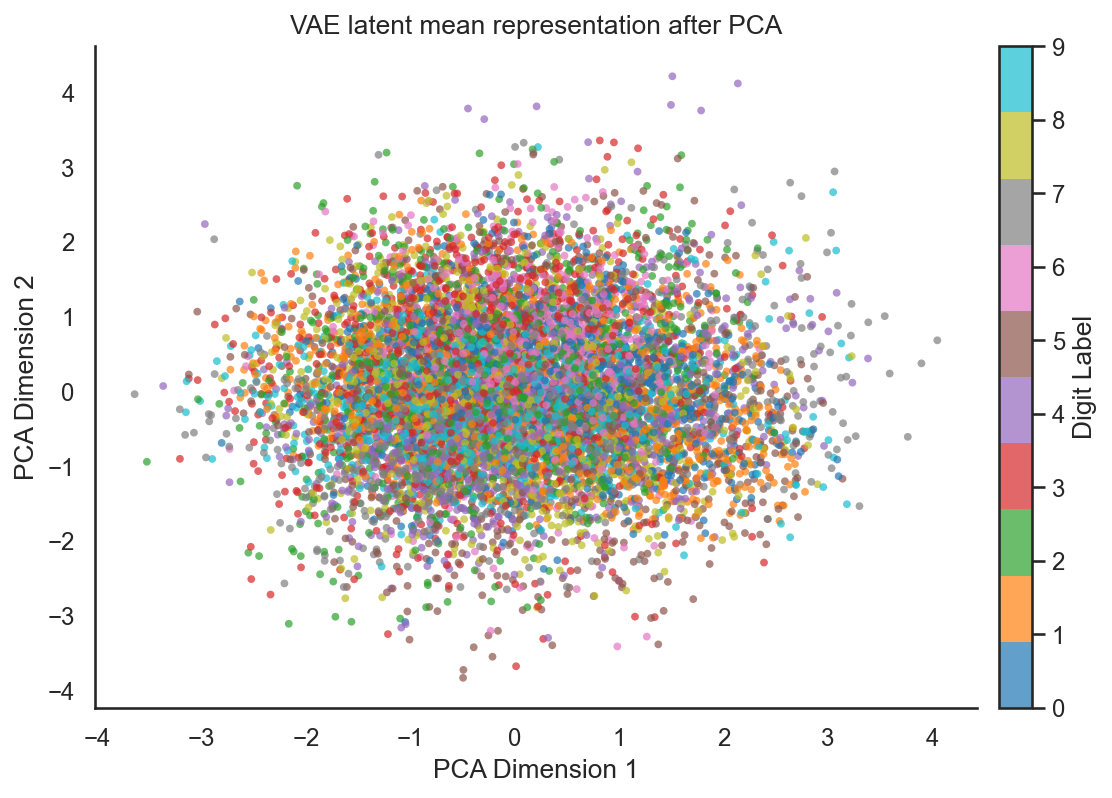

In [34]:
fig, ax = plt.subplots(figsize=(8, 5.5))

scatter = ax.scatter(
    latent_2d[:, 0],
    latent_2d[:, 1],
    c=latent_labels,
    cmap="tab10",
    s=14,
    alpha=0.70,
    edgecolors="none",
)

cbar = plt.colorbar(scatter, ax=ax, ticks=range(10), pad=0.02)
cbar.set_label("Digit Label")

ax.set_title("VAE latent mean representation after PCA")
ax.set_xlabel("PCA Dimension 1")
ax.set_ylabel("PCA Dimension 2")
sns.despine(ax=ax)
plt.tight_layout()

if SAVE_FIGURES:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(OUTPUT_DIR / "vae_mnist_latent_pca.png", dpi=300, bbox_inches="tight")
    fig.savefig(OUTPUT_DIR / "vae_mnist_latent_pca.svg", bbox_inches="tight")

## 9. Latent interpolation with conditions

下面选取几对不同数字，把它们编码成 `mu` vectors，在原始 64 维 latent space 中做直线插值。

为了可视化从一个 digit 到另一个 digit 的变化，下面也对 one-hot condition 做线性插值。端点仍然是标准 one-hot label；中间点可以理解为一种课堂可视化用的 soft condition。实际 conditional generation 时，通常直接使用明确的 one-hot digit label。

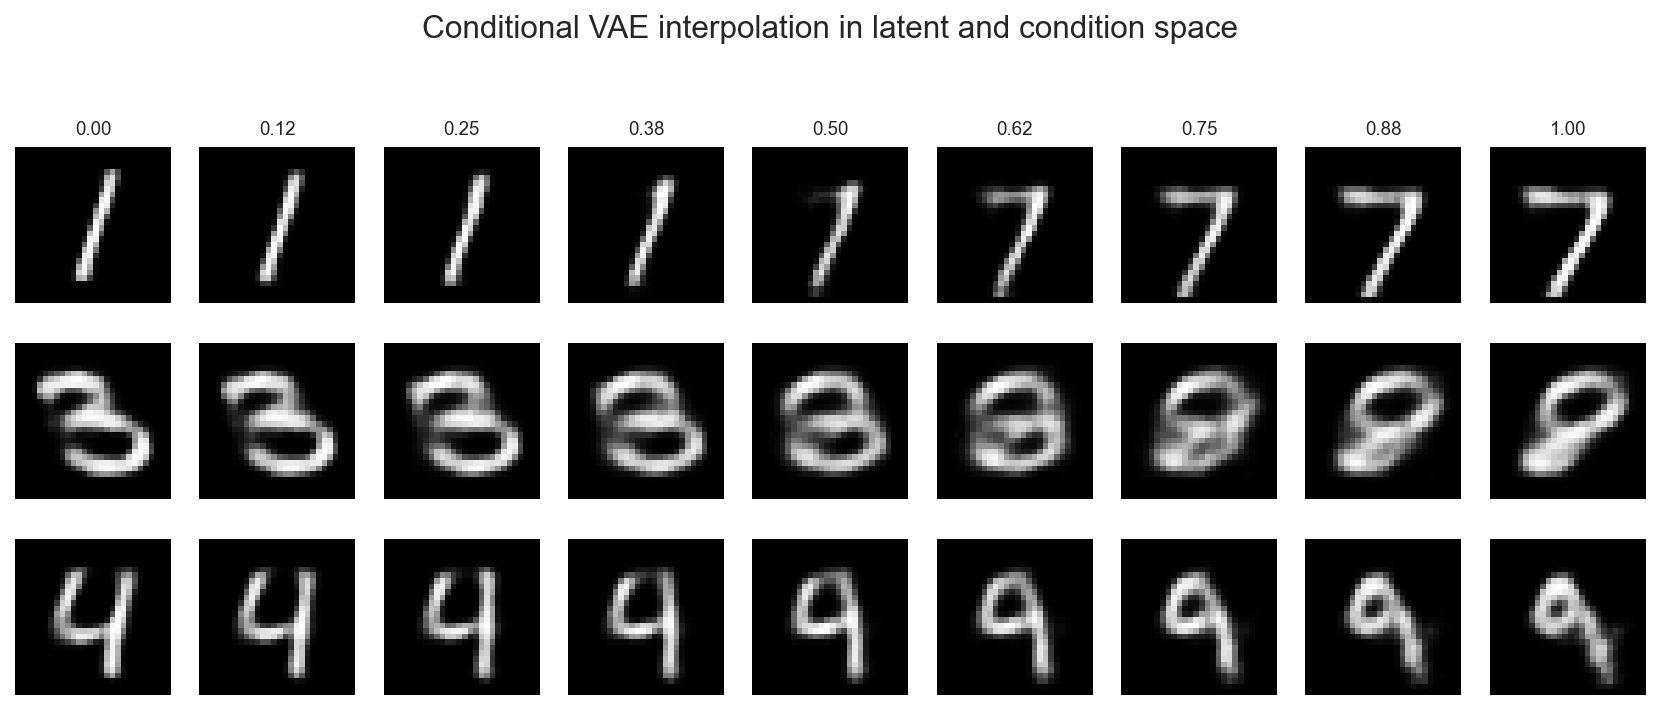

In [35]:
def find_first_image_with_label(dataset, target_label):
    for image, label in dataset:
        if label == target_label:
            return image, label
    raise ValueError(f"Label {target_label} not found")


def interpolate_between_digits(model, dataset, start_digit, end_digit, steps=9):
    start_image, _ = find_first_image_with_label(dataset, start_digit)
    end_image, _ = find_first_image_with_label(dataset, end_digit)

    model.eval()
    with torch.no_grad():
        start_batch = start_image.unsqueeze(0).to(device)
        end_batch = end_image.unsqueeze(0).to(device)
        start_label = torch.tensor([start_digit], device=device)
        end_label = torch.tensor([end_digit], device=device)

        start_mu, _ = model.encode(start_batch, start_label)
        end_mu, _ = model.encode(end_batch, end_label)

        alphas = torch.linspace(0, 1, steps, device=device).unsqueeze(1)
        latent_path = (1 - alphas) * start_mu + alphas * end_mu

        start_condition = labels_to_one_hot(start_label, NUM_CLASSES)
        end_condition = labels_to_one_hot(end_label, NUM_CLASSES)
        condition_path = (1 - alphas) * start_condition + alphas * end_condition

        decoded = model.decode_with_condition_vector(latent_path, condition_path).view(steps, 1, 28, 28).cpu()

    return decoded, alphas.squeeze(1).cpu().numpy()


digit_pairs = [(1, 7), (3, 8), (4, 9)]
interpolation_steps = 9

fig, axes = plt.subplots(
    len(digit_pairs),
    interpolation_steps,
    figsize=(1.25 * interpolation_steps, 1.6 * len(digit_pairs)),
)

for row, (start_digit, end_digit) in enumerate(digit_pairs):
    decoded_images, alphas = interpolate_between_digits(
        model,
        test_dataset,
        start_digit=start_digit,
        end_digit=end_digit,
        steps=interpolation_steps,
    )

    for col in range(interpolation_steps):
        ax = axes[row, col]
        ax.imshow(decoded_images[col].squeeze(0), cmap="gray")
        ax.axis("off")
        if row == 0:
            ax.set_title(f"{alphas[col]:.2f}", fontsize=9)

    axes[row, 0].set_ylabel(f"{start_digit} → {end_digit}", fontsize=11)

fig.suptitle("Conditional VAE interpolation in latent and condition space", y=1.02)
plt.tight_layout()

if SAVE_FIGURES:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(OUTPUT_DIR / "conditional_vae_mnist_latent_interpolation.png", dpi=300, bbox_inches="tight")
    fig.savefig(OUTPUT_DIR / "conditional_vae_mnist_latent_interpolation.svg", bbox_inches="tight")

## 10. Conditional generation from the prior

Conditional VAE 可以先采样：

$$z \sim \mathcal{N}(0, I)$$

再指定 label condition $y$，用 decoder 生成对应数字。下面每一行固定一个 digit label，每一列使用一个随机 latent vector。

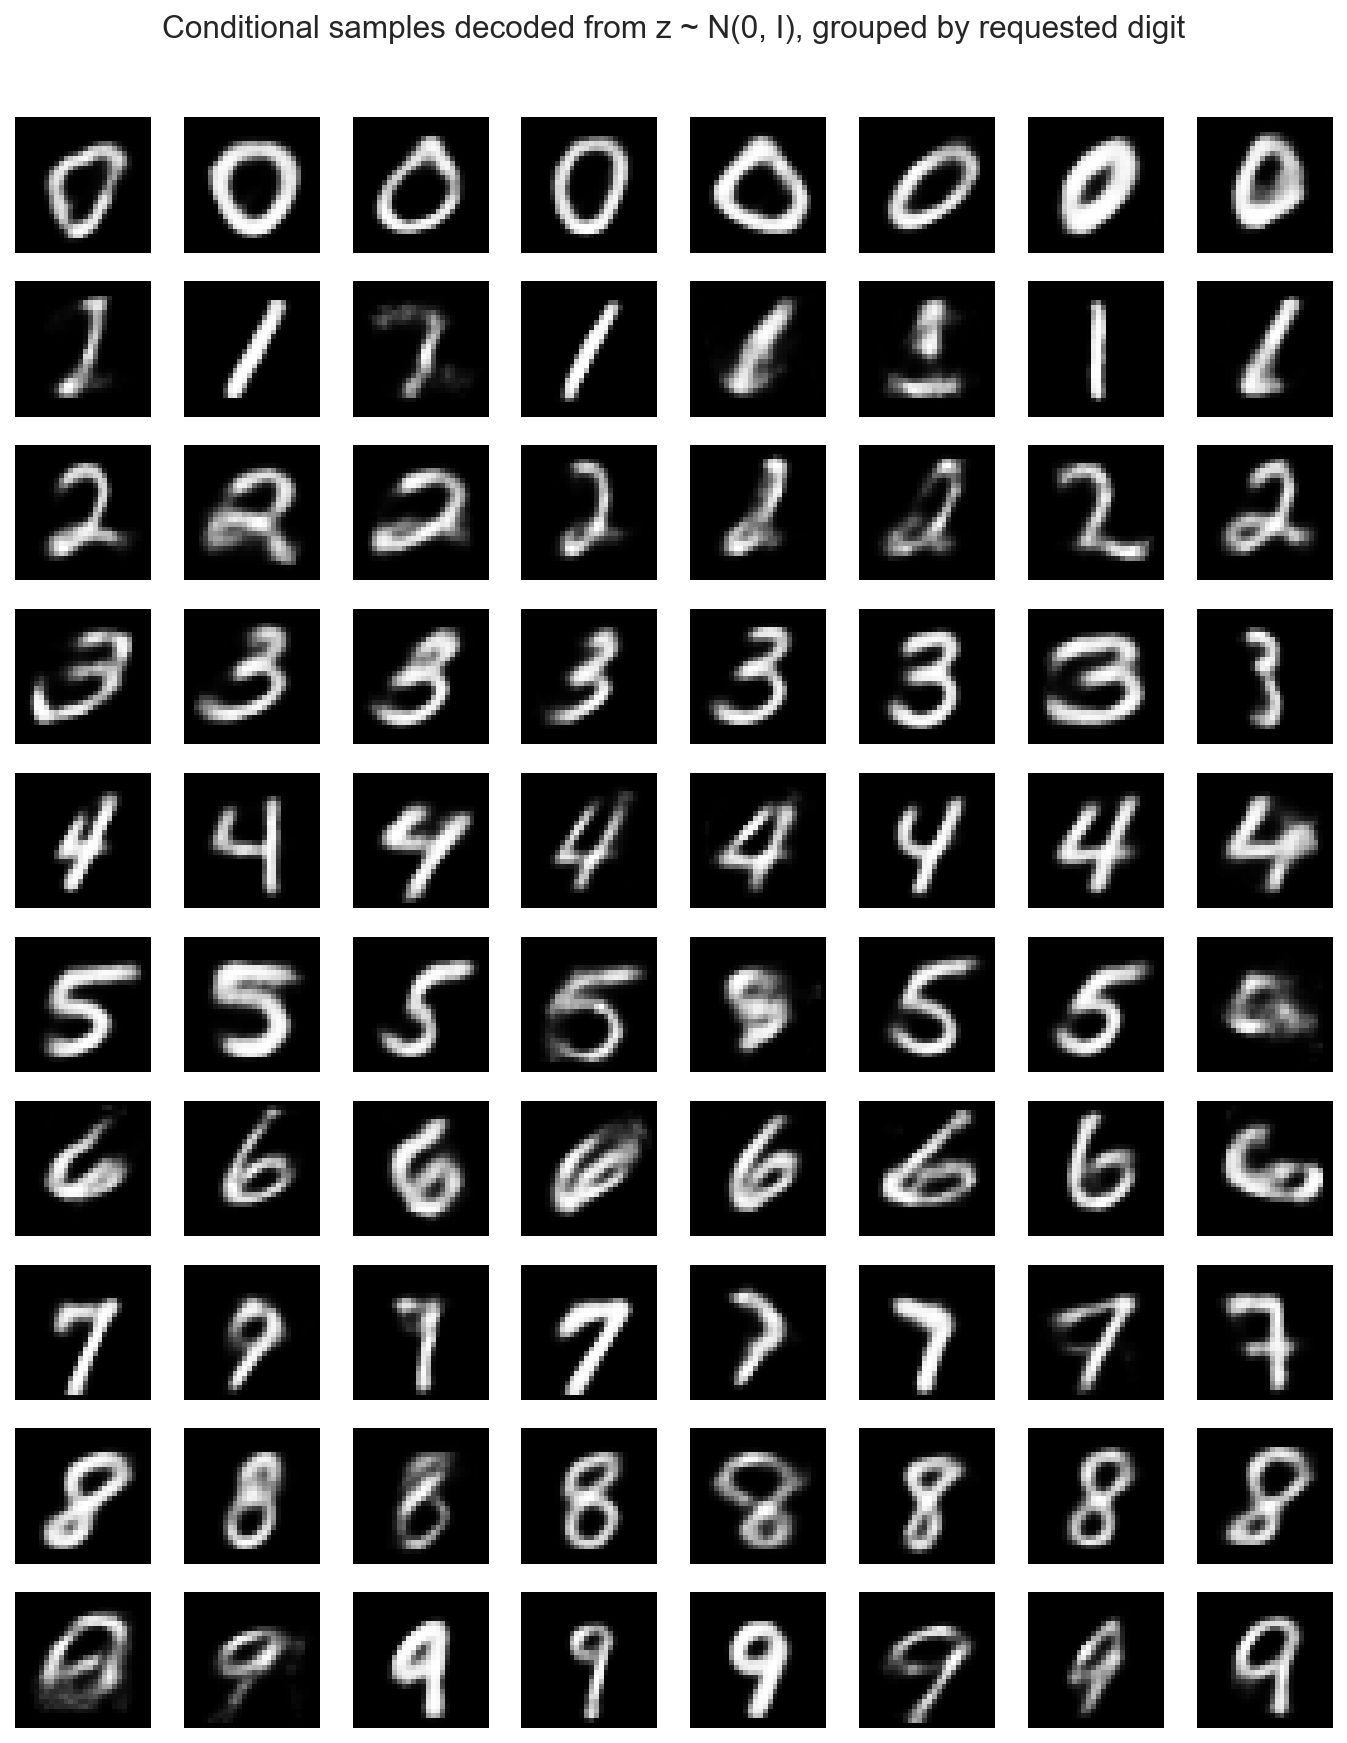

In [36]:
model.eval()
samples_per_digit = 8
digits = torch.arange(NUM_CLASSES, device=device)
condition_labels = digits.repeat_interleave(samples_per_digit)
num_samples = condition_labels.shape[0]

with torch.no_grad():
    random_latent = torch.randn(num_samples, LATENT_DIM, device=device)
    generated = model.decode(random_latent, condition_labels).view(num_samples, 1, 28, 28).cpu()

fig, axes = plt.subplots(NUM_CLASSES, samples_per_digit, figsize=(1.15 * samples_per_digit, 1.15 * NUM_CLASSES))
for digit in range(NUM_CLASSES):
    for col in range(samples_per_digit):
        index = digit * samples_per_digit + col
        ax = axes[digit, col]
        ax.imshow(generated[index].squeeze(0), cmap="gray")
        ax.axis("off")
        if col == 0:
            ax.set_ylabel(str(digit), rotation=0, labelpad=10, fontsize=11)

fig.suptitle("Conditional samples decoded from z ~ N(0, I), grouped by requested digit", y=1.01)
plt.tight_layout()

if SAVE_FIGURES:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(OUTPUT_DIR / "conditional_vae_mnist_prior_samples.png", dpi=300, bbox_inches="tight")
    fig.savefig(OUTPUT_DIR / "conditional_vae_mnist_prior_samples.svg", bbox_inches="tight")

## 11. 小结

本 notebook 展示了 Conditional VAE 的基本流程：

1. Encoder 接收 `(x, y)`，输出 `mu` 和 `logvar`，表示 $q(z \mid x, y)$。
2. Reparameterization trick 用 $z = \mu + \sigma \odot \epsilon$ 采样 latent vector。
3. Decoder 接收 `(z, y)`，重建或生成图片。
4. VAE loss 包含 reconstruction loss 和 KL loss；condition label 是模型输入，不是额外的分类 loss。
5. PCA 可以可视化 64 维 `mu` vectors，但 PCA 坐标不是 decoder 的输入空间。
6. Conditional generation 在原始 64 维 latent space 中采样，并用 label condition 指定要生成的数字。

和普通 VAE 相比，Conditional VAE 可以显式控制生成类别。理想情况下，label $y$ 控制数字类别，latent vector $z$ 控制同一类别内部的风格变化。

## 12. 可以自己尝试的问题

- 把 `BETA` 改成 `0.1`、`1.0`、`4.0`，观察 reconstruction、KL、PCA 和 conditional samples 的变化。
- 把 `LATENT_DIM = 64` 改成 `16` 或 `128`，比较 latent PCA 和 conditional generation。
- 固定同一个 random latent vector，分别用 0 到 9 的 labels decode，观察 label condition 控制了什么。
- 更换 `digit_pairs`，观察 soft condition interpolation 是否平滑。
- 比较 AutoEncoder、VAE 和 Conditional VAE 的 interpolation：哪一个更平滑，哪一个类别控制更明确？